### Transfer Learning

In [2]:
#importing libraries
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import load_model


In [4]:
#loading and preprocessing dataset

images_train = np.load("data/images_train.npy")/255.
images_valid = np.load("data/images_valid.npy")/255.
images_test = np.load("data/images_test.npy")/255.

labels_train = np.load("data/labels_train.npy")
labels_valid = np.load("data/labels_valid.npy")
labels_test = np.load("data/labels_test.npy")

In [6]:
print(f"{images_train.shape[0]} training data examples")
print(f"{images_valid.shape[0]} validation data examples")
print(f"{images_test.shape[0]} test data examples")

600 training data examples
300 validation data examples
300 test data examples


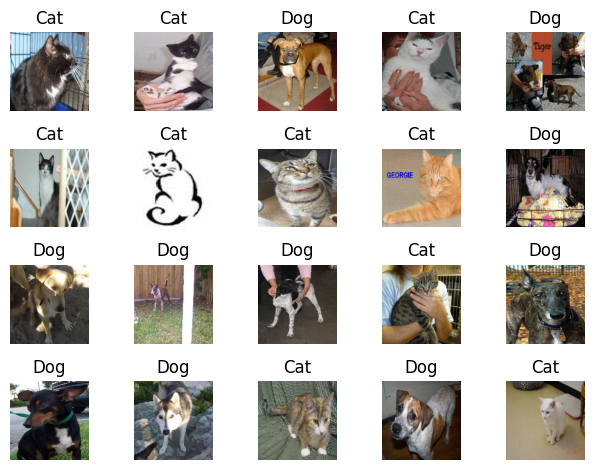

In [9]:
#sample images and labels to display

class_names = np.array(['Dog', 'Cat'])

sample_indexes = np.random.choice(images_train.shape[0], 20, replace=False)
for i, inx in enumerate(sample_indexes):
    plt.subplot(4,5,i+1)
    plt.imshow(images_train[inx])
    plt.title(class_names[labels_train[inx]])
    plt.axis("off") 
plt.tight_layout() 
  

In [14]:
#defining benchmark model

def get_benchmark_model(input_shape):
    
    input_layer = Input(shape=input_shape)
    x = Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(input_layer)
    x = Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
    x = MaxPooling2D(pool_size=2)(x)
    x = Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
    x = Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
    x = MaxPooling2D(pool_size=2)(x)
    x = Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
    x = Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
    x = MaxPooling2D(pool_size=2)(x)
    x = Flatten()(x)
    x = Dense(units=128, activation="relu")(x)
    x = Dense(units=1, activation="sigmoid")(x)

    model = Model(inputs=input_layer, outputs=x)

    model.compile(tf.keras.optimizers.RMSprop(learning_rate=0.001),
                 loss="binary_crossentropy",
                  metrics=['accuracy'] )
    
    return model



In [15]:
images_train[0].shape


(160, 160, 3)

In [16]:
model = get_benchmark_model(input_shape=images_train[0].shape)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,840,865 (26.10 MB)

 Trainable params: 6,840,865 (26.10 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#training the CNN benchmark model
from tensorflow.keras.callbacks import EarlyStopping

earlystopping = EarlyStopping(monitor="val_loss", mode="min", patience=6)
model = get_benchmark_model(input_shape=images_train[0].shape)
history = model.fit(images_train, labels_train, epochs=30, batch_size=32,
                    validation_data = (images_valid, labels_valid),
                    callbacks=[earlystopping])

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 353ms/step - accuracy: 0.5233 - loss: 1.0146 - val_accuracy: 0.5500 - val_loss: 0.6921
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.5167 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 330ms/step - accuracy: 0.5433 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.7045
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.4983 - loss: 0.6992 - val_accuracy: 0.5933 - val_loss: 0.6855
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 330ms/step - accuracy: 0.6033 - loss: 0.6906 - val_accuracy: 0.5633 - val_loss: 0.6824
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 328ms/step - accuracy: 0.5417 - loss: 0.6938 - val_accuracy: 0.5233 - val_loss: 0.6851
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 340ms/step - accuracy: 0.5667 - loss: 0.6801 - val_accuracy: 0.5267 - val_loss: 0.6887
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 337ms/step - accuracy: 0.6067 - loss: 0.7076 - val_accuracy: 0.

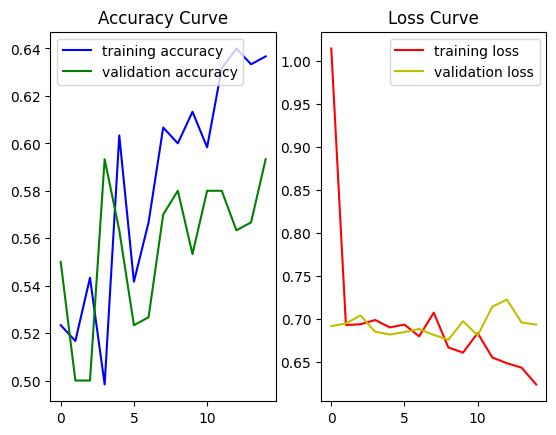

In [26]:
def visual_plot(history):

    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']

    plt.subplot(1,2,1)
    plt.plot(accuracy, 'b', label="training accuracy")
    plt.plot(val_accuracy, 'g', label="validation accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, 'r', label="training loss")
    plt.plot(val_loss, 'y', label="validation loss")
    plt.title("Loss Curve")
    plt.legend()

visual_plot(history)

In [25]:
#evaluating benchmark model on test data

benchmark_model_loss, benchmark_model_accuracy = model.evaluate(images_test, labels_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6000 - loss: 0.6877


In [34]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights="imagenet",
                         include_top=True,
                         input_shape=images_train[0].shape)

base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
#removing last layer of base model to add our custom layers
def trim_base_model(pretrained_model):

    inp = pretrained_model.input
    outp = pretrained_model.layers[-2].output
    feature_extractor = Model(inputs=inp, outputs=outp)

    return feature_extractor

In [49]:
feature_extractor = trim_base_model(base_model)
feature_extractor.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [50]:
#add new classifier head

def add_new_classifier_head(feature_extractor_model):

    new_model = Sequential([
        feature_extractor_model,
        Dense(32, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    return new_model

In [51]:
new_model = add_new_classifier_head(feature_extractor)
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_7 (Functional)       │ (None, 1280)           │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 2,264,897 (8.64 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [52]:
#freezing the weights of the pretrained model

def freeze_pretrained_weights(model):

    model.get_layer("functional_7").trainable=False

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
                  loss="binary_crossentropy",
                  metrics=['accuracy'])
    
    return model

In [53]:
frozen_new_model=freeze_pretrained_weights(new_model)
frozen_new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_7 (Functional)       │ (None, 1280)           │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 41,025 (160.25 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [54]:
#training the model

earlystopping = tf.keras.callbacks.EarlyStopping(patience=2)

history_frozen_new_model = frozen_new_model.fit(images_train, labels_train,
epochs=30, batch_size=32, validation_data=(images_valid, labels_valid),
callbacks=[earlystopping])

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step - accuracy: 0.8400 - loss: 0.3536 - val_accuracy: 0.9500 - val_loss: 0.1585
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.9483 - loss: 0.1545 - val_accuracy: 0.9567 - val_loss: 0.1170
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.9617 - loss: 0.1092 - val_accuracy: 0.9533 - val_loss: 0.1086
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.9683 - loss: 0.0845 - val_accuracy: 0.9533 - val_loss: 0.1134
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.9617 - loss: 0.0828 - val_accuracy: 0.9600 - val_loss: 0.1195


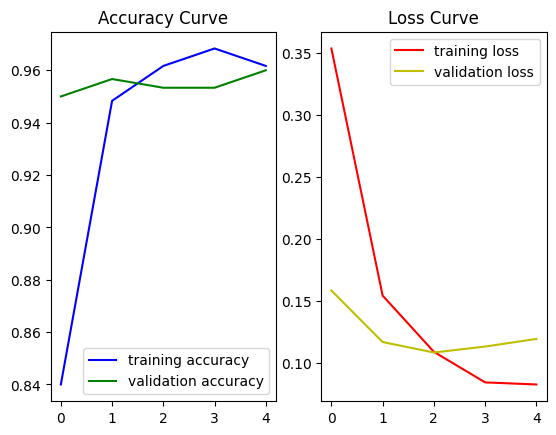

In [55]:
def visual_plot(history):

    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']

    plt.subplot(1,2,1)
    plt.plot(accuracy, 'b', label="training accuracy")
    plt.plot(val_accuracy, 'g', label="validation accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, 'r', label="training loss")
    plt.plot(val_loss, 'y', label="validation loss")
    plt.title("Loss Curve")
    plt.legend()

visual_plot(history=history_frozen_new_model)

In [56]:
#model evaulation

new_model_test_loss, new_model_test_acc = frozen_new_model.evaluate(images_test, labels_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.9733 - loss: 0.0830


In [ ]:
#comparing both models

